In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("zara-clothes.csv", sep=";")
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [201]:
df_man = df.loc[df["section"] == "MAN"]
df_woman = df.loc[df["section"] == "WOMAN"]
print(df_woman["terms"].unique())

['sweaters']


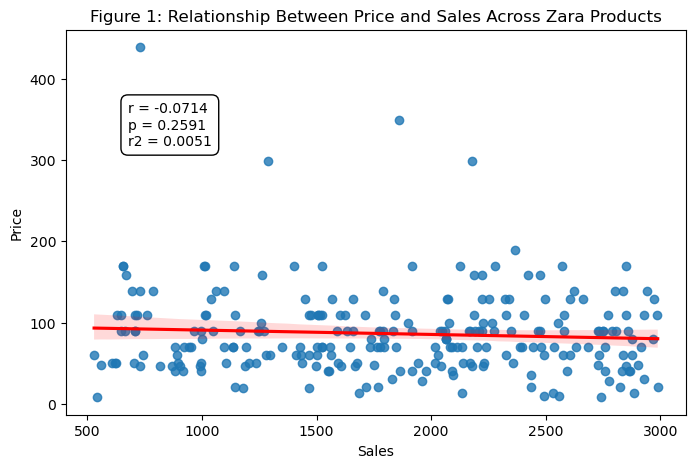

In [ ]:
plt.figure(figsize=(8,5))
r,p = stats.pearsonr(df["Sales Volume"], df["price"])
r2 = r**2
reg = sns.regplot(data=df, x="Sales Volume", y="price", line_kws={"color": "red"})
text = f"""r = {r:.4f}
p = {p:.4f}
r2 = {r2:.4f}"""
reg.text(
0.1,
0.7,
text,
transform = reg.transAxes,
bbox = {"boxstyle":"round, pad=0.5", "fc":"white"}
)
plt.title("Figure 1: Relationship Between Price and Sales Across Zara Products")
plt.xlabel("Sales")
plt.ylabel("Price")
plt.show()

/var/folders/x7/7dqylsbj44z2sj73w7w4lmqw0000gn/T/ipykernel_50610/1970023320.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = f"""t = {t:.4f}


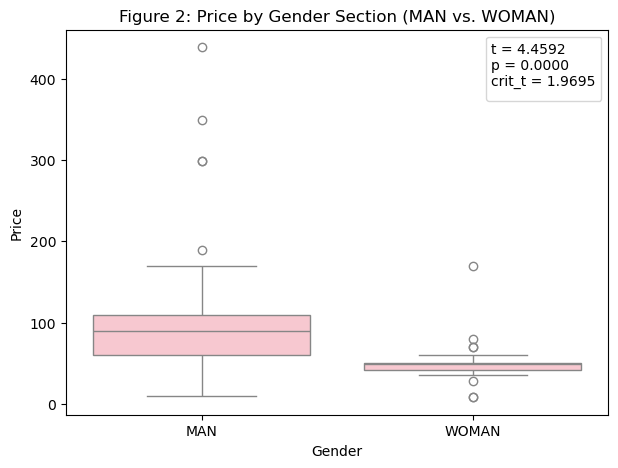

In [205]:
man = df.loc[df["section"] == "MAN", "price"]
woman = df.loc[df["section"] == "WOMAN", "price"]
t,p = stats.ttest_ind(man, woman)

deg_f = len(man) + len(woman) - 2
alpha = 0.05
crit_t = stats.t.ppf(1 - alpha / 2, deg_f)

plt.figure(figsize=(7,5))
sns.boxplot(x="section", y="price", data=df, color="pink")

plt.title("Figure 2: Price by Gender Section (MAN vs. WOMAN)")
plt.xlabel("Gender")
plt.ylabel("Price")

plt.legend(title = f"""t = {t:.4f}
p = {p:.4f}
crit_t = {crit_t:.4f}""")
plt.show()

/var/folders/x7/7dqylsbj44z2sj73w7w4lmqw0000gn/T/ipykernel_50610/297404718.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = f"""t = {t:.4f}


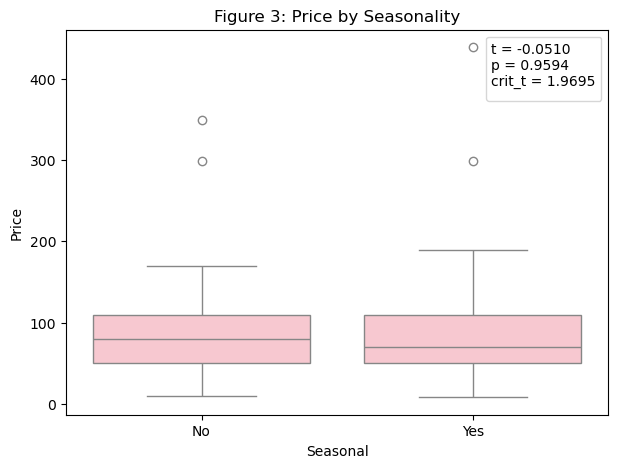

In [207]:
seasonal = df.loc[df["Seasonal"] == "Yes", "price"]
not_seasonal = df.loc[df["Seasonal"] == "No", "price"]
t,p = stats.ttest_ind(seasonal, not_seasonal)

deg_f = len(seasonal) + len(not_seasonal) - 2
alpha = 0.05
crit_t = stats.t.ppf(1 - alpha / 2, deg_f)

plt.figure(figsize=(7,5))
sns.boxplot(x="Seasonal", y="price", data=df, color="pink")

plt.title("Figure 3: Price by Seasonality")
plt.xlabel("Seasonal")
plt.ylabel("Price")

plt.legend(title = f"""t = {t:.4f}
p = {p:.4f}
crit_t = {crit_t:.4f}""")
plt.show()

/var/folders/x7/7dqylsbj44z2sj73w7w4lmqw0000gn/T/ipykernel_50610/640521668.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = f"""f = {f:.4f}


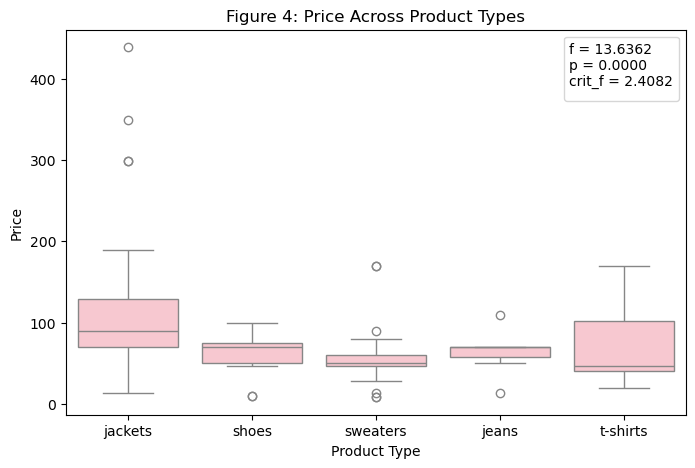

In [208]:
product = [df.loc[df["terms"] == var, "price"] for var in cols]

f, p = stats.f_oneway(*samples)
dfb = len(df["terms"].unique()) - 1
dfw = len(df["price"]) - len(df["terms"].unique())
alpha = 0.05
crit_f = stats.f.ppf(1 - alpha, dfb, dfw)


plt.figure(figsize=(8,5))
pos_boxes = sns.boxplot(
    data=df,
    x="terms",
    y="price",
    color="pink"
)
plt.title("Figure 4: Price Across Product Types")
plt.xlabel("Product Type")
plt.ylabel("Price")
plt.legend(title = f"""f = {f:.4f}
p = {p:.4f}
crit_f = {crit_f:.4f}""")

plt.show()

In [209]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['price'], groups=df['terms'], alpha=0.05)
print(tukey)

results_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
print("\nSignificant pairs only:")
print(results_df[results_df['reject'] == True])

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1   group2  meandiff p-adj   lower    upper   reject
----------------------------------------------------------
 jackets    jeans -41.8342 0.1129 -89.3024    5.634  False
 jackets    shoes -40.8844 0.0002 -66.8043 -14.9644   True
 jackets sweaters -50.8952    0.0 -74.0833 -27.7072   True
 jackets t-shirts -38.3301 0.0005 -63.9163 -12.7439   True
   jeans    shoes   0.9498    1.0 -50.8332  52.7328  False
   jeans sweaters  -9.0611 0.9879 -59.5321    41.41  False
   jeans t-shirts   3.5041 0.9997 -48.1127  55.1209  False
   shoes sweaters -10.0109 0.9022 -41.0904  21.0687  False
   shoes t-shirts   2.5543 0.9995 -30.3533  35.4618  False
sweaters t-shirts  12.5651 0.7953 -18.2366  43.3669  False
----------------------------------------------------------

Significant pairs only:
    group1    group2  meandiff   p-adj    lower    upper  reject
1  jackets     shoes  -40.8844  0.0002 -66.8043 -14.9644    True
2  jackets  sweater

Jackets are the outlier — they are significantly more expensive than shoes, sweaters, and t-shirts. However, the jackets vs. jeans comparison, despite a ~€42 gap, does not reach significance. That's almost certainly a sample size issue: there are only 8 jeans in the dataset, which gives very low statistical power for that specific comparison.